In [ ]:
import os
import torch
torch.set_default_dtype(torch.double)

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.starflow import StarFlowDistribution
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean
from src.training._denoising_score_matching import DenoisingScoreMatchingTraining
from src.transforms.vector.parity.simple_tanh import SimpleTanhParityVectorTransform
from src.transforms.vector.linear.lower_triangular import LowerTriangularLinearVectorTransform
from src.transforms.vector.linear.upper_triangular import UpperTriangularLinearVectorTransform

results_folder = os.path.join("results", "tree", "three_phase")
# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


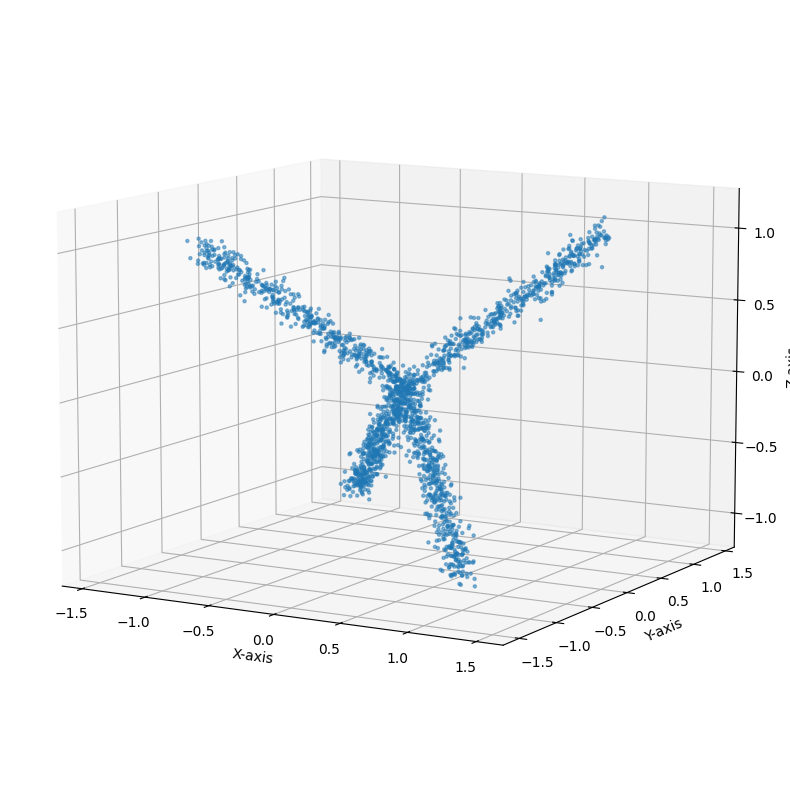

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [4]:
# construct transform diffeomorphism
class SimpleStarFlowVectorDiffeomorphism(StarFlowVectorDiffeomorphism):
    def __init__(self, dim, hidden_dim, n_flows, num_radials, latent_dim=None, sigma=1e-2):
        super(SimpleStarFlowVectorDiffeomorphism, self).__init__(dim, StarFlow(self.create_transform(dim, hidden_dim, n_flows), self.create_star_gaussian(dim, num_radials, latent_dim, sigma)))

    def create_transform(self, dim, hidden_dim, n_flows):
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(UpperTriangularLinearVectorTransform(dim))
            transforms_list.append(LowerTriangularLinearVectorTransform(dim))
            transforms_list.append(SimpleTanhParityVectorTransform(dim, hidden_dim, parity=i))
        transforms_list.append(UpperTriangularLinearVectorTransform(dim))
        transforms_list.append(LowerTriangularLinearVectorTransform(dim))
        transform = transforms.CompositeTransform(transforms_list)
        return transform
    
    def create_star_gaussian(self, dim, num_radials, latent_dim, sigma):
        return MultiInverseLinearStarNormGaussianDistribution(dim, num_radials, r=latent_dim, sigma=sigma)

# construct transform diffeomorphism trainer
dim = 3
hidden_dim = 8
n_flows = 2
num_radials = 2
    
# instantiate GME-informed star flow
dsm_trainer = DenoisingScoreMatchingTraining(SimpleStarFlowVectorDiffeomorphism(dim, hidden_dim, n_flows, num_radials), lr=1e-2)


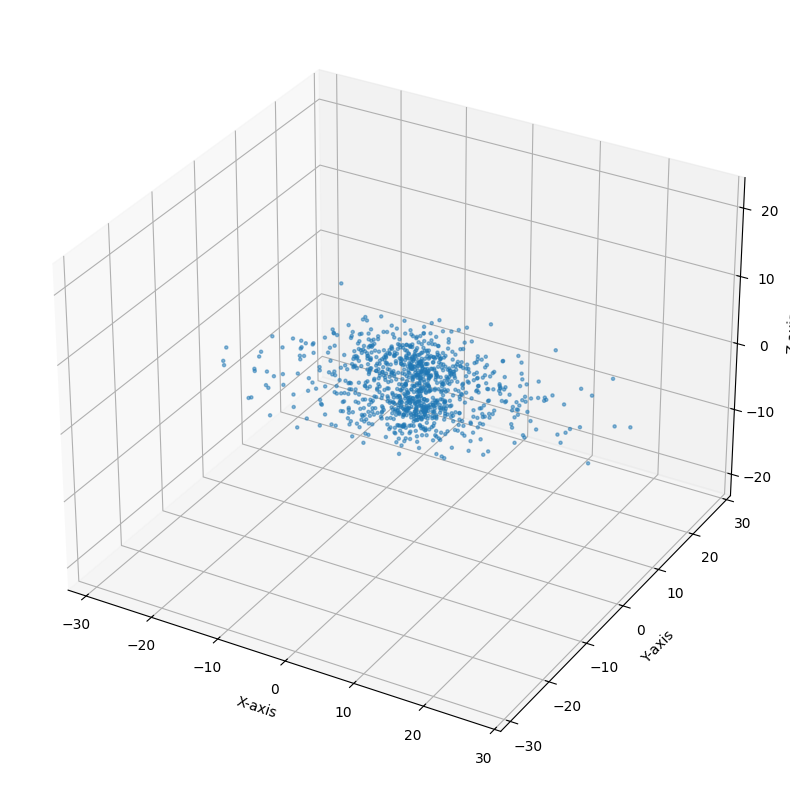

In [5]:
# sample from star flow
num_samples = 1000
with torch.no_grad():
    samples = dsm_trainer.starflow_diffeo.starflow.sample(num_samples)


plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='3d')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"samples_before_training.png"))
plt.show()

In [6]:
# construct train loop for the decoding diffeomorphism
num_epochs_flow = 200
sigmas = [0.5, 0.1]
for sigma in sigmas:
    for epoch in range(num_epochs_flow):
        epoch_loss = 0.0
        for x, _ in dataloader:
            loss = dsm_trainer.train_step(x, sigma=sigma)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(pair_dataset)
        print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Sigma: {sigma}, Loss: {epoch_loss:.6f}")

phi = dsm_trainer.starflow_diffeo

Flow Epoch 1/200, Sigma: 0.5, Loss: 2.818869
Flow Epoch 2/200, Sigma: 0.5, Loss: 2.558392
Flow Epoch 3/200, Sigma: 0.5, Loss: 2.468327
Flow Epoch 4/200, Sigma: 0.5, Loss: 2.310436
Flow Epoch 5/200, Sigma: 0.5, Loss: 2.114889
Flow Epoch 6/200, Sigma: 0.5, Loss: 1.951018
Flow Epoch 7/200, Sigma: 0.5, Loss: 1.950073
Flow Epoch 8/200, Sigma: 0.5, Loss: 1.966864
Flow Epoch 9/200, Sigma: 0.5, Loss: 1.887578
Flow Epoch 10/200, Sigma: 0.5, Loss: 1.891816
Flow Epoch 11/200, Sigma: 0.5, Loss: 1.865192
Flow Epoch 12/200, Sigma: 0.5, Loss: 1.871827
Flow Epoch 13/200, Sigma: 0.5, Loss: 1.885817
Flow Epoch 14/200, Sigma: 0.5, Loss: 1.874729
Flow Epoch 15/200, Sigma: 0.5, Loss: 1.860283
Flow Epoch 16/200, Sigma: 0.5, Loss: 1.821315
Flow Epoch 17/200, Sigma: 0.5, Loss: 1.888370
Flow Epoch 18/200, Sigma: 0.5, Loss: 1.798306
Flow Epoch 19/200, Sigma: 0.5, Loss: 1.751653
Flow Epoch 20/200, Sigma: 0.5, Loss: 1.804023
Flow Epoch 21/200, Sigma: 0.5, Loss: 1.704220
Flow Epoch 22/200, Sigma: 0.5, Loss: 1.6710

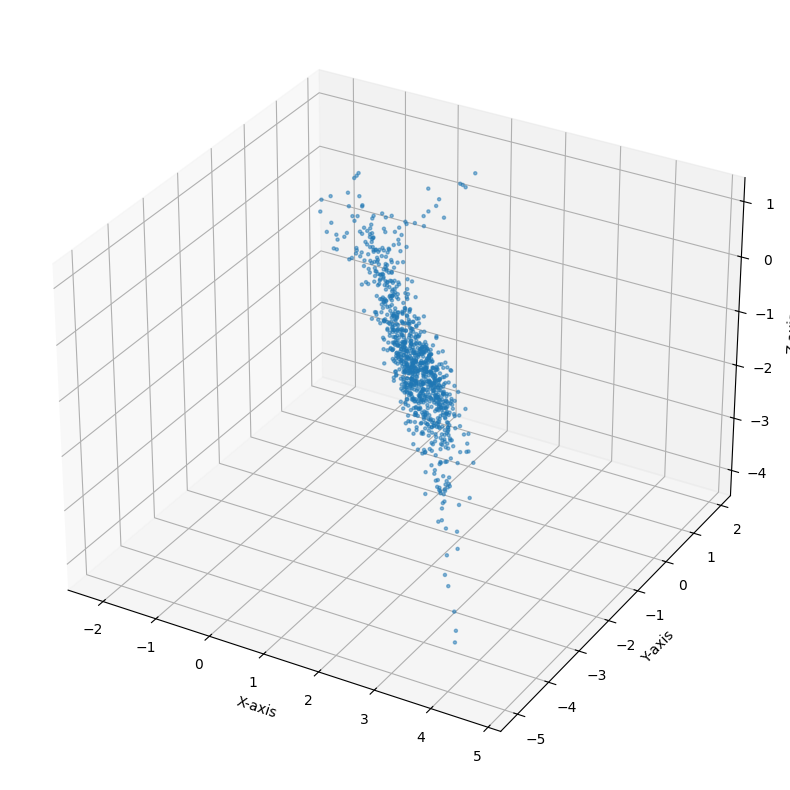

In [7]:
# sample from star flow
num_samples = 1000
with torch.no_grad():
    samples = dsm_trainer.starflow_diffeo.starflow.sample(num_samples)


plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='3d')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"samples_after_training.png"))
plt.show()

In [8]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackVectorEuclidean(phi)
# construct iso_manifold
iso_phi_manifold = l2IsometrizedVectorEuclidean(phi_manifold)

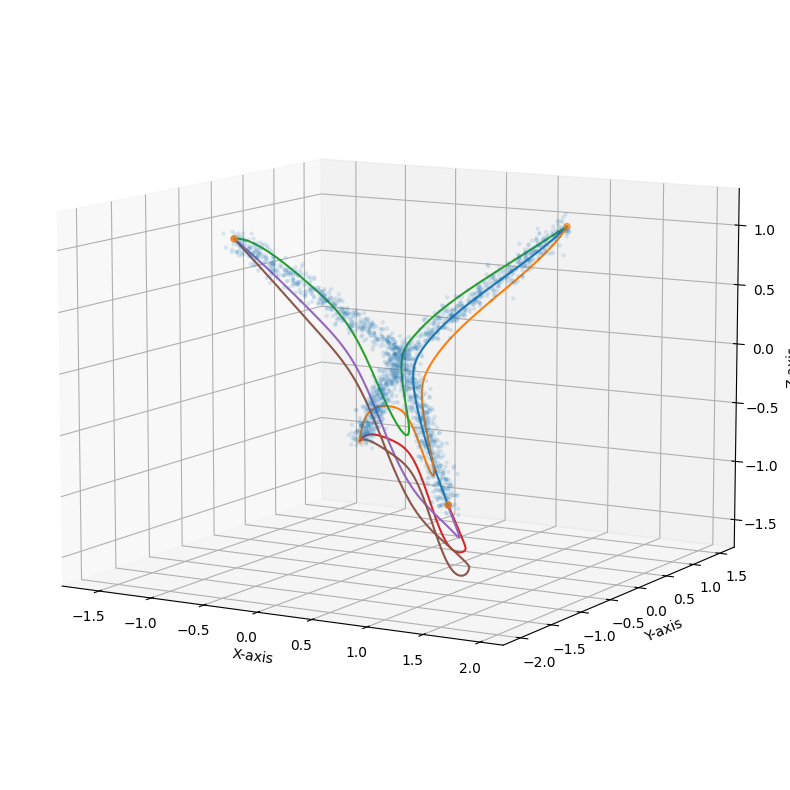

In [9]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    phi_geodesics = iso_phi_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_geodesics[0, i, j, :, 0].numpy(), phi_geodesics[0, i, j, :, 1].numpy(), phi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_geodesics.png"))
plt.show()

iteration 1 | error = 0.3049664954131987
iteration 2 | error = 0.2429900364511205
iteration 3 | error = 0.19089152819934976
iteration 4 | error = 0.15541149558404008
iteration 5 | error = 0.12814863710537666
iteration 6 | error = 0.10904902606597215
iteration 7 | error = 0.07831763772747821
iteration 8 | error = 0.061215642288328674
iteration 9 | error = 0.05001433387715339
iteration 10 | error = 0.035043333027878966
iteration 11 | error = 0.03157213173584297
iteration 12 | error = 0.019765925695902273
iteration 13 | error = 0.019362533162935923
iteration 14 | error = 0.011097778464792957
iteration 15 | error = 0.008246005121474328
iteration 16 | error = 0.006278398426621325
iteration 17 | error = 0.0045632930166400465
iteration 18 | error = 0.0035554558685654655
iteration 19 | error = 0.0025442125238984425
iteration 20 | error = 0.002019295481548666
gradient descent was terminated after reaching a error 0.002019295481548666 in 20 iterations
Computing rank 2 approximation on tangent sp

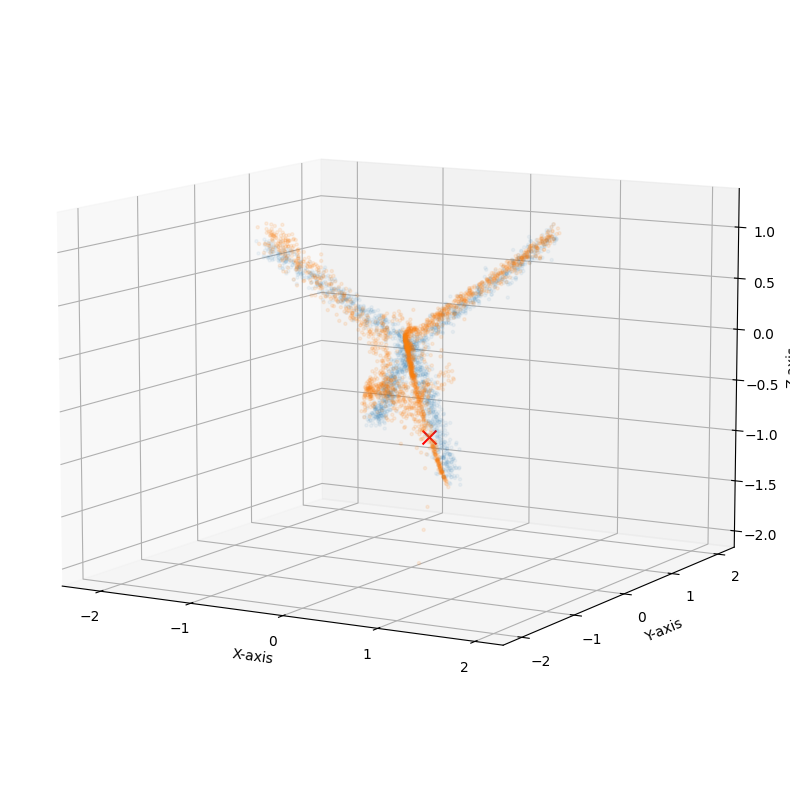

Mean reconstruction error after compression: 0.3015338001576946


In [10]:
# compute data barycentre
phi_barycentre_data = iso_phi_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_phi_bary = l2TangentSpacePCAVectorSolver(data, iso_phi_manifold, phi_barycentre_data)
# compute principal directions
_, phi_compressed_data, _ = l2_pga_solver_phi_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(phi_compressed_data[:, 0].numpy(), phi_compressed_data[:, 1].numpy(), phi_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(phi_barycentre_data[0].item(), phi_barycentre_data[1].item(), phi_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - phi_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

In [11]:
# compare embeddings
phi_pca_embedding = l2_pga_solver_phi_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(phi_pca_embedding[:, 0], phi_pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"phi_emb_comparison.png"))
plt.show()

NameError: name 'embeddings_centered' is not defined

<Figure size 800x800 with 0 Axes>

### Stage 3: Learn a Diffeomorphic Decoder-informed Star Distribution ###

In [ ]:
# construct bimodal Star Gaussian 
num_radials = 2
latent_star_gaussian_trainer = LatentStarGaussianTraining(phi, MultiInverseLinearStarNormGaussianDistribution(dim, num_radials=num_radials), lr=1e-2)

In [ ]:
# construct training loop for the radial function
num_epochs_flow = 500
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        loss = latent_star_gaussian_trainer.train_step(x)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

psi = latent_star_gaussian_trainer.psi

Flow Epoch 1/500, Loss: 6.489874
Flow Epoch 2/500, Loss: 5.486752
Flow Epoch 3/500, Loss: 4.796207
Flow Epoch 4/500, Loss: 4.275192
Flow Epoch 5/500, Loss: 3.864795
Flow Epoch 6/500, Loss: 3.529046
Flow Epoch 7/500, Loss: 3.250038
Flow Epoch 8/500, Loss: 3.009899
Flow Epoch 9/500, Loss: 2.803554
Flow Epoch 10/500, Loss: 2.621475
Flow Epoch 11/500, Loss: 2.459572
Flow Epoch 12/500, Loss: 2.317303
Flow Epoch 13/500, Loss: 2.188428
Flow Epoch 14/500, Loss: 2.075008
Flow Epoch 15/500, Loss: 1.969103
Flow Epoch 16/500, Loss: 1.873475
Flow Epoch 17/500, Loss: 1.787818
Flow Epoch 18/500, Loss: 1.709332
Flow Epoch 19/500, Loss: 1.637120
Flow Epoch 20/500, Loss: 1.571366
Flow Epoch 21/500, Loss: 1.508814
Flow Epoch 22/500, Loss: 1.453253
Flow Epoch 23/500, Loss: 1.399602
Flow Epoch 24/500, Loss: 1.351497
Flow Epoch 25/500, Loss: 1.308336
Flow Epoch 26/500, Loss: 1.264563
Flow Epoch 27/500, Loss: 1.224634
Flow Epoch 28/500, Loss: 1.187441
Flow Epoch 29/500, Loss: 1.156405
Flow Epoch 30/500, Loss

In [ ]:
# construct manifold from learned flow
phi_psi_manifold = StandardPullbackVectorEuclidean(CompositionDiffeomorphism([phi, psi]))
# construct iso_manifold 
iso_phi_psi_manifold = l2IsometrizedVectorEuclidean(phi_psi_manifold)

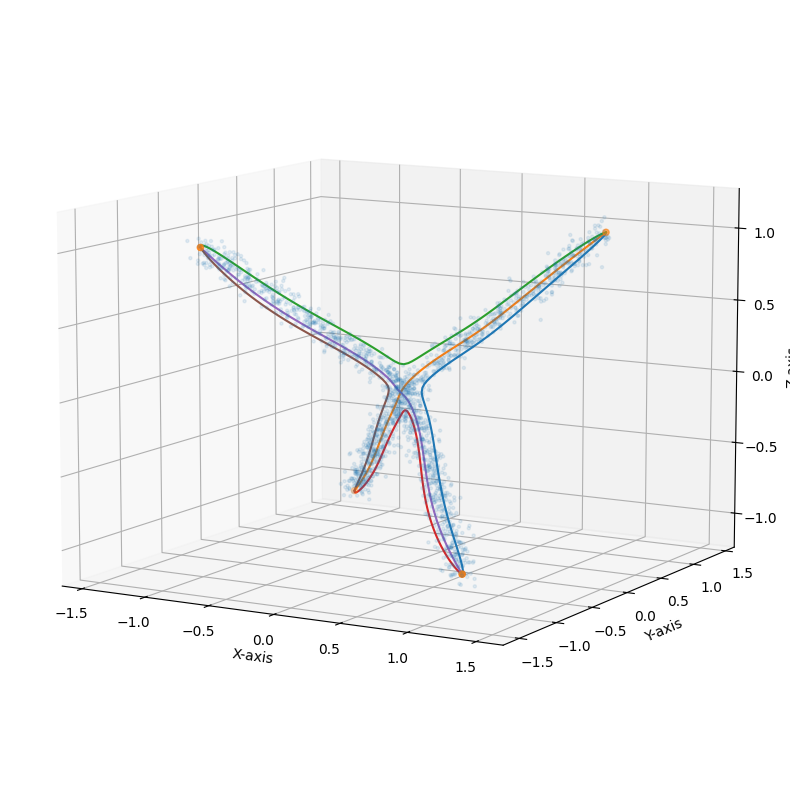

In [ ]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    phi_psi_geodesics = iso_phi_psi_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_psi_geodesics[0, i, j, :, 0].numpy(), phi_psi_geodesics[0, i, j, :, 1].numpy(), phi_psi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_psi_geodesics.png"))
plt.show()

iteration 1 | error = 0.0032202515724594947
iteration 2 | error = 0.0009809969531685053
iteration 3 | error = 0.0009747018895259704
iteration 4 | error = 0.0009747013653813848
iteration 5 | error = 0.0009747013627414579
iteration 6 | error = 0.0009747013623022729
iteration 7 | error = 0.0009747013597942143
iteration 8 | error = 0.0009747013574786179
iteration 9 | error = 0.0009747013553561349
iteration 10 | error = 0.0009747013534263323
iteration 11 | error = 0.0009747013516892947
iteration 12 | error = 0.0009747013501451771
iteration 13 | error = 0.00097470134879375
iteration 14 | error = 0.000974701347634973
iteration 15 | error = 0.0009747013466687773
iteration 16 | error = 0.0009747013458953772
iteration 17 | error = 0.0009747013453145013
iteration 18 | error = 0.0009747013449265649
iteration 19 | error = 0.0009747013447312263
iteration 20 | error = 0.0009747013447286519
gradient descent was terminated after reaching a error 0.0009747013447286519 in 20 iterations
Computing rank 2 a

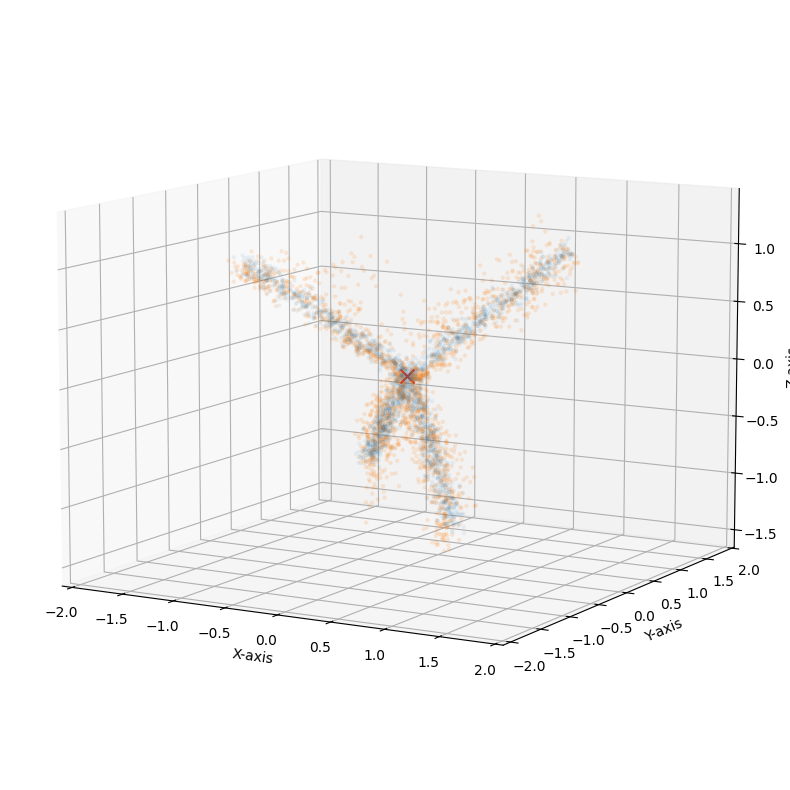

Mean reconstruction error after compression: 0.14551098392558043


In [ ]:
# compute data barycentre
phi_psi_barycentre_data = iso_phi_psi_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_phi_psi_bary = l2TangentSpacePCAVectorSolver(data, iso_phi_psi_manifold, phi_psi_barycentre_data)
# compute principal directions
_, phi_psi_compressed_data, _ = l2_pga_solver_phi_psi_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(phi_psi_compressed_data[:, 0].numpy(), phi_psi_compressed_data[:, 1].numpy(), phi_psi_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(phi_psi_barycentre_data[0].item(), phi_psi_barycentre_data[1].item(), phi_psi_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_psi_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - phi_psi_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

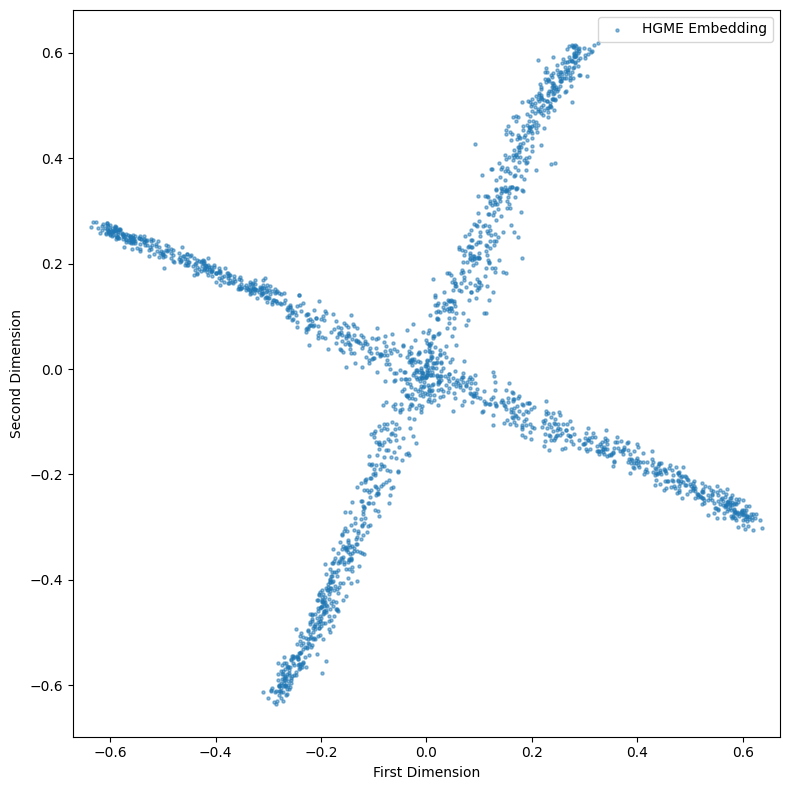

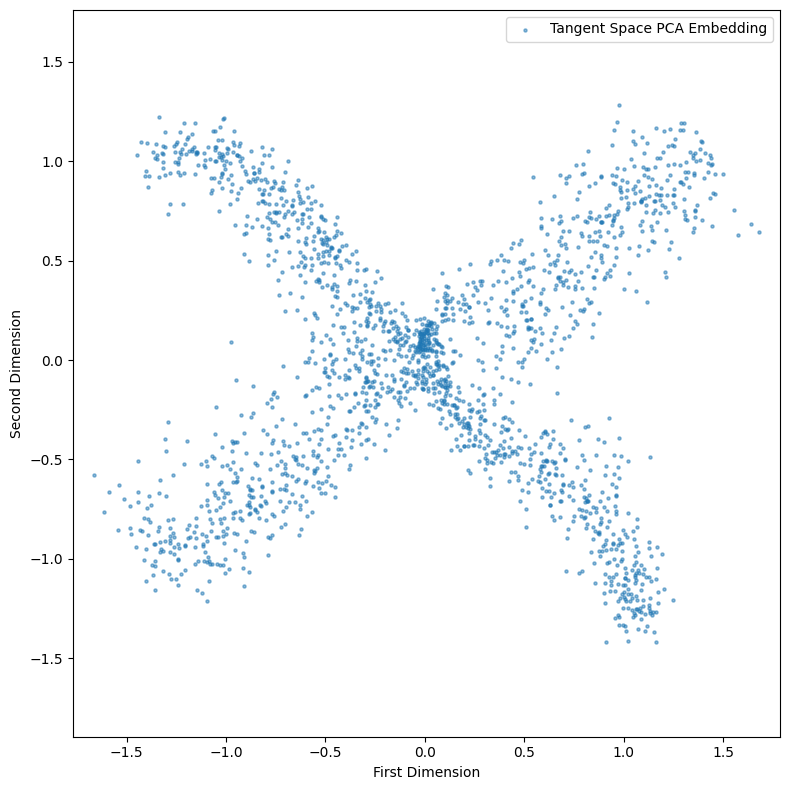

In [ ]:
# compare embeddings
phi_psi_pca_embedding = l2_pga_solver_phi_psi_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(phi_psi_pca_embedding[:, 0], phi_psi_pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"phi_psi_emb_comparison.png"))
plt.show()